In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
TensorFlow : 2.20.0
GPU        : []


In [2]:
!pip install opencv-python-headless scikit-image -q
print("Done!")

Done!


In [ ]:
import os, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from skimage import filters, morphology, measure, feature
from skimage.color import rgb2gray
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications        import EfficientNetB3
from tensorflow.keras.models              import Model
from tensorflow.keras.layers              import (GlobalAveragePooling2D,
                                                   Dense, Dropout,
                                                   BatchNormalization)
from tensorflow.keras.callbacks           import (ModelCheckpoint,
                                                   EarlyStopping,
                                                   ReduceLROnPlateau)
from tensorflow.keras.optimizers          import Adam
from sklearn.metrics                      import (classification_report,
                                                   confusion_matrix)
print("All libraries imported!")

All libraries imported!


In [ ]:

BASE_DIR  = "/content/drive/MyDrive/Plant_Leaf_Disease"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")


IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS_P1  = 10
EPOCHS_P2  = 20
LR_P1      = 1e-3
LR_P2      = 1e-4


SAVE_DIR  = "/content/drive/MyDrive/LeafDisease_Outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH  = os.path.join(SAVE_DIR, "best_model.keras")
TFLITE_PATH = os.path.join(SAVE_DIR, "leaf_disease.tflite")
LABELS_PATH = os.path.join(SAVE_DIR, "class_names.json")

print("Checking folders...")
for name, path in [("train", TRAIN_DIR),
                   ("val",   VAL_DIR),
                   ("test",  TEST_DIR)]:
    classes = os.listdir(path)
    total   = sum(len(os.listdir(os.path.join(path, c)))
                  for c in classes
                  if os.path.isdir(os.path.join(path, c)))
    print(f"  {name:<6} → {len(classes):>2} classes | "
          f"{total:>6} images  ✓")

Checking folders...
  train  → 23 classes |  68196 images  ✓
  val    → 23 classes |   8514 images  ✓
  test   → 23 classes |   8547 images  ✓


In [ ]:
print("=" * 60)
print("  PHASE 2 — PREPROCESSING & AUGMENTATION")
print("=" * 60)

train_datagen = ImageDataGenerator(
    rescale            = 1./255,   # normalize [0,1]
    rotation_range     = 15,       # rotate ±15°
    zoom_range         = 0.2,      # zoom 20%
    horizontal_flip    = True,     # mirror
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    shear_range        = 0.1,
    fill_mode          = "nearest"
)


val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    shuffle     = True
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    shuffle     = False
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    shuffle     = False
)

NUM_CLASSES = train_gen.num_classes
CLASS_NAMES = list(train_gen.class_indices.keys())

print(f"\n  Classes  : {NUM_CLASSES}")
print(f"  Train    : {train_gen.samples:,} images")
print(f"  Val      : {val_gen.samples:,} images")
print(f"  Test     : {test_gen.samples:,} images")
print(f"\n  Class list:")
for name, idx in train_gen.class_indices.items():
    print(f"    {idx:>2}. {name}")

  PHASE 2 — PREPROCESSING & AUGMENTATION
Found 68196 images belonging to 23 classes.
Found 8514 images belonging to 23 classes.
Found 8547 images belonging to 23 classes.

  Classes  : 23
  Train    : 68,196 images
  Val      : 8,514 images
  Test     : 8,547 images

  Class list:
     0. Bell pepper Bacterial spot
     1. Bell pepper Healthy
     2. Corn Common rust
     3. Corn Gray leaf spot
     4. Corn Healthy
     5. Corn Northern Leaf Blight
     6. Grape Black Measles
     7. Grape Black rot
     8. Grape Healthy
     9. Grape Isariopsis Leaf Spot
    10. Potato Early blight
    11. Potato Healthy
    12. Potato Late blight
    13. Tomato Bacterial spot
    14. Tomato Early blight
    15. Tomato Healthy
    16. Tomato Late blight
    17. Tomato Leaf Mold
    18. Tomato Mosaic virus
    19. Tomato Septoria leaf spot
    20. Tomato Spider mites
    21. Tomato Target Spot
    22. Tomato Yellow Leaf Curl Virus


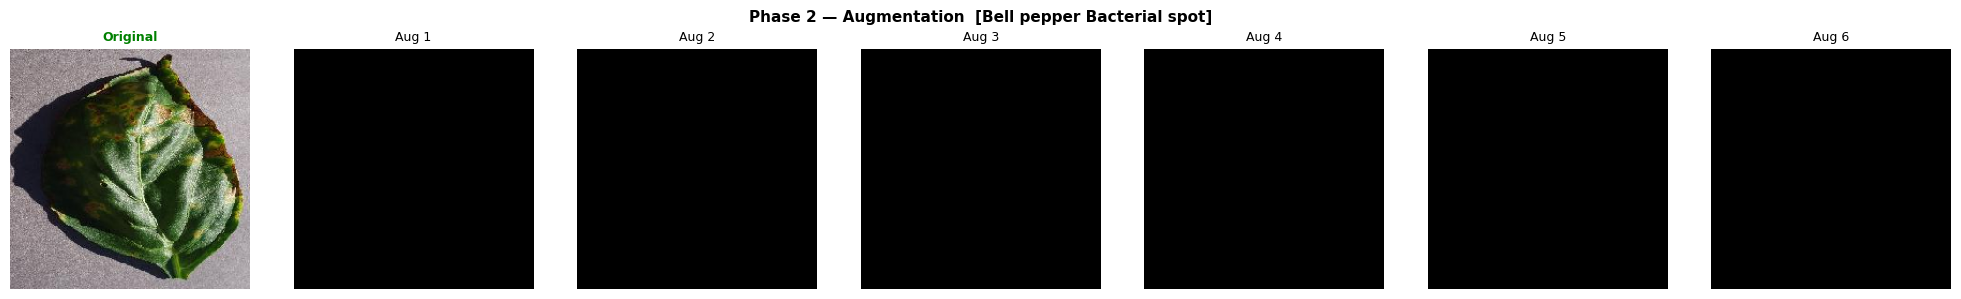

  Phase 2 complete!


In [ ]:
# Pick one sample image and show original vs augmented
sample_cls     = CLASS_NAMES[0]
sample_dir     = os.path.join(TRAIN_DIR, sample_cls)
sample_path    = os.path.join(sample_dir,
                               os.listdir(sample_dir)[0])

from tensorflow.keras.preprocessing.image import load_img, img_to_array
img_arr = img_to_array(
    load_img(sample_path, target_size=IMG_SIZE)) / 255.0
img_arr = np.expand_dims(img_arr, 0)

aug_gen  = train_datagen.flow(img_arr, batch_size=1)
aug_imgs = [next(aug_gen)[0] for _ in range(6)]

fig, axes = plt.subplots(1, 7, figsize=(20, 3))
axes[0].imshow(img_arr[0])
axes[0].set_title("Original", fontsize=9,
                   color="green", fontweight="bold")
axes[0].axis("off")

for i, aug in enumerate(aug_imgs):
    axes[i+1].imshow(np.clip(aug, 0, 1))
    axes[i+1].set_title(f"Aug {i+1}", fontsize=9)
    axes[i+1].axis("off")

plt.suptitle(f"Phase 2 — Augmentation  [{sample_cls}]",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "augmentation.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  Phase 2 complete!")

  PHASE 3 — IMAGE SEGMENTATION
  Thresholding → Region Growing → Morphology


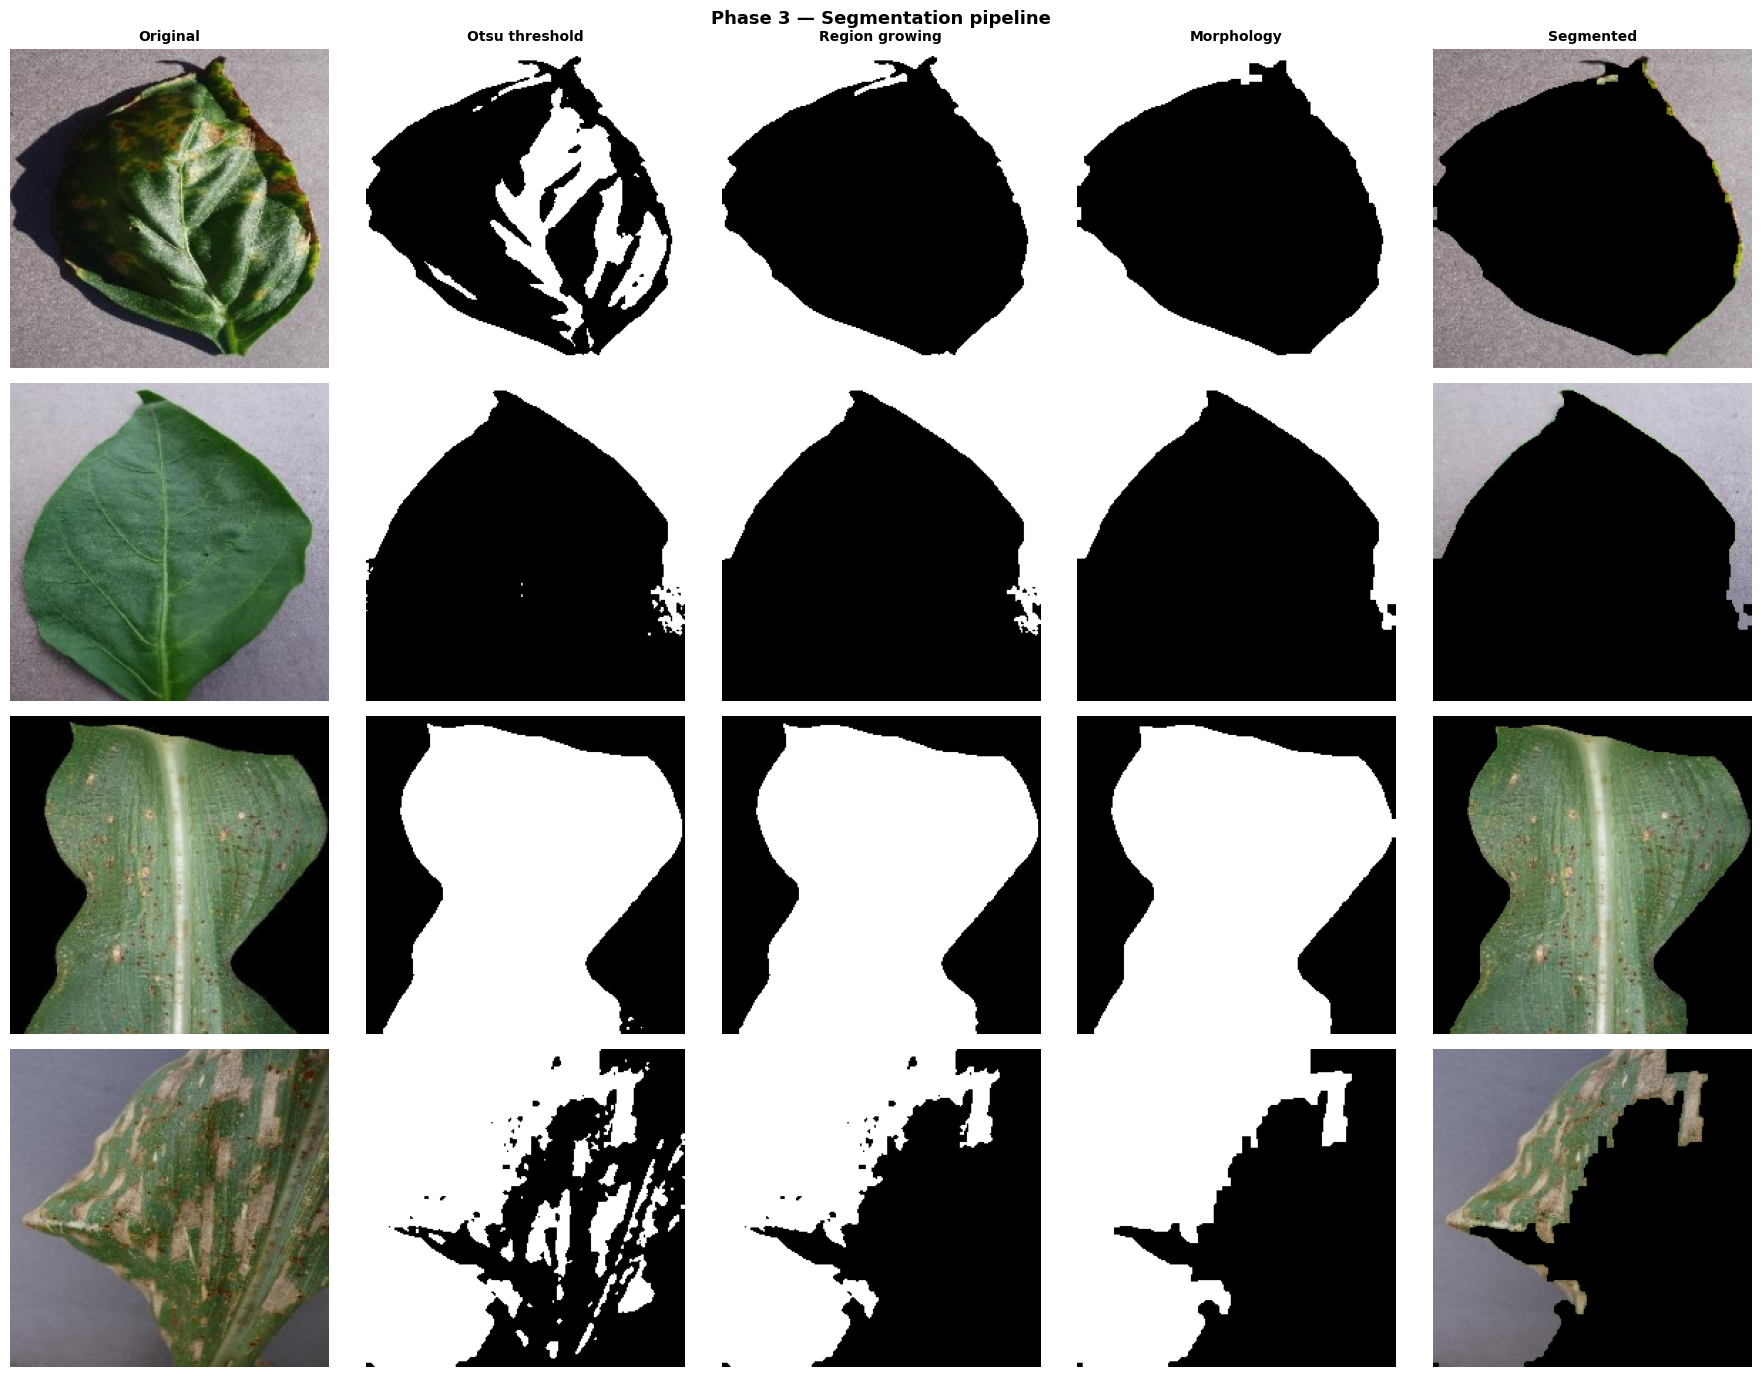

  Phase 3 complete!


In [ ]:
print("=" * 60)
print("  PHASE 3 — IMAGE SEGMENTATION")
print("  Thresholding → Region Growing → Morphology")
print("=" * 60)

def segment_leaf(img_path, img_size=(224, 224)):
    """
    3-step segmentation:
    1. Otsu thresholding  — leaf vs background
    2. Region growing     — keep largest connected region
    3. Morphological ops  — opening (noise) + closing (holes)
    """
    img   = cv2.imread(img_path)
    img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img   = cv2.resize(img, img_size)
    gray  = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Step 1 — Gaussian smooth + Otsu threshold
    blur     = cv2.GaussianBlur(gray, (5, 5), 0)
    _, otsu  = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Step 2 — Region growing (largest connected region)
    labeled = measure.label(otsu)
    props   = measure.regionprops(labeled)
    if props:
        largest     = max(props, key=lambda r: r.area)
        region_mask = (labeled == largest.label
                       ).astype(np.uint8) * 255
    else:
        region_mask = otsu

    # Step 3 — Morphological opening + closing
    kernel = np.ones((5, 5), np.uint8)
    opened = cv2.morphologyEx(
        region_mask, cv2.MORPH_OPEN,  kernel)  # remove noise
    closed = cv2.morphologyEx(
        opened,      cv2.MORPH_CLOSE, kernel)  # fill holes

    # Overlay
    mask_3ch = cv2.merge([closed, closed, closed])
    overlay  = cv2.bitwise_and(img, mask_3ch)

    return img, otsu, region_mask, closed, overlay

# Visualize on 4 classes
sample_classes = CLASS_NAMES[:4]
fig, axes = plt.subplots(4, 5, figsize=(18, 14))

titles = ["Original", "Otsu threshold",
          "Region growing", "Morphology", "Segmented"]
for col, t in enumerate(titles):
    axes[0][col].set_title(t, fontsize=10,
                            fontweight="bold")

for row, cls in enumerate(sample_classes):
    cls_dir  = os.path.join(TRAIN_DIR, cls)
    img_file = os.path.join(cls_dir,
                             os.listdir(cls_dir)[0])
    orig, otsu, region, morph, overlay = segment_leaf(img_file)

    for col, data in enumerate(
            [orig, otsu, region, morph, overlay]):
        cmap = "gray" if col in [1, 2, 3] else None
        axes[row][col].imshow(data, cmap=cmap)
        axes[row][col].axis("off")
    axes[row][0].set_ylabel(cls, fontsize=7,
                             rotation=0,
                             labelpad=90, va="center")

plt.suptitle("Phase 3 — Segmentation pipeline",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "segmentation.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  Phase 3 complete!")

  PHASE 4 — FEATURE EXTRACTION
  LoG edge detection + Blob detection


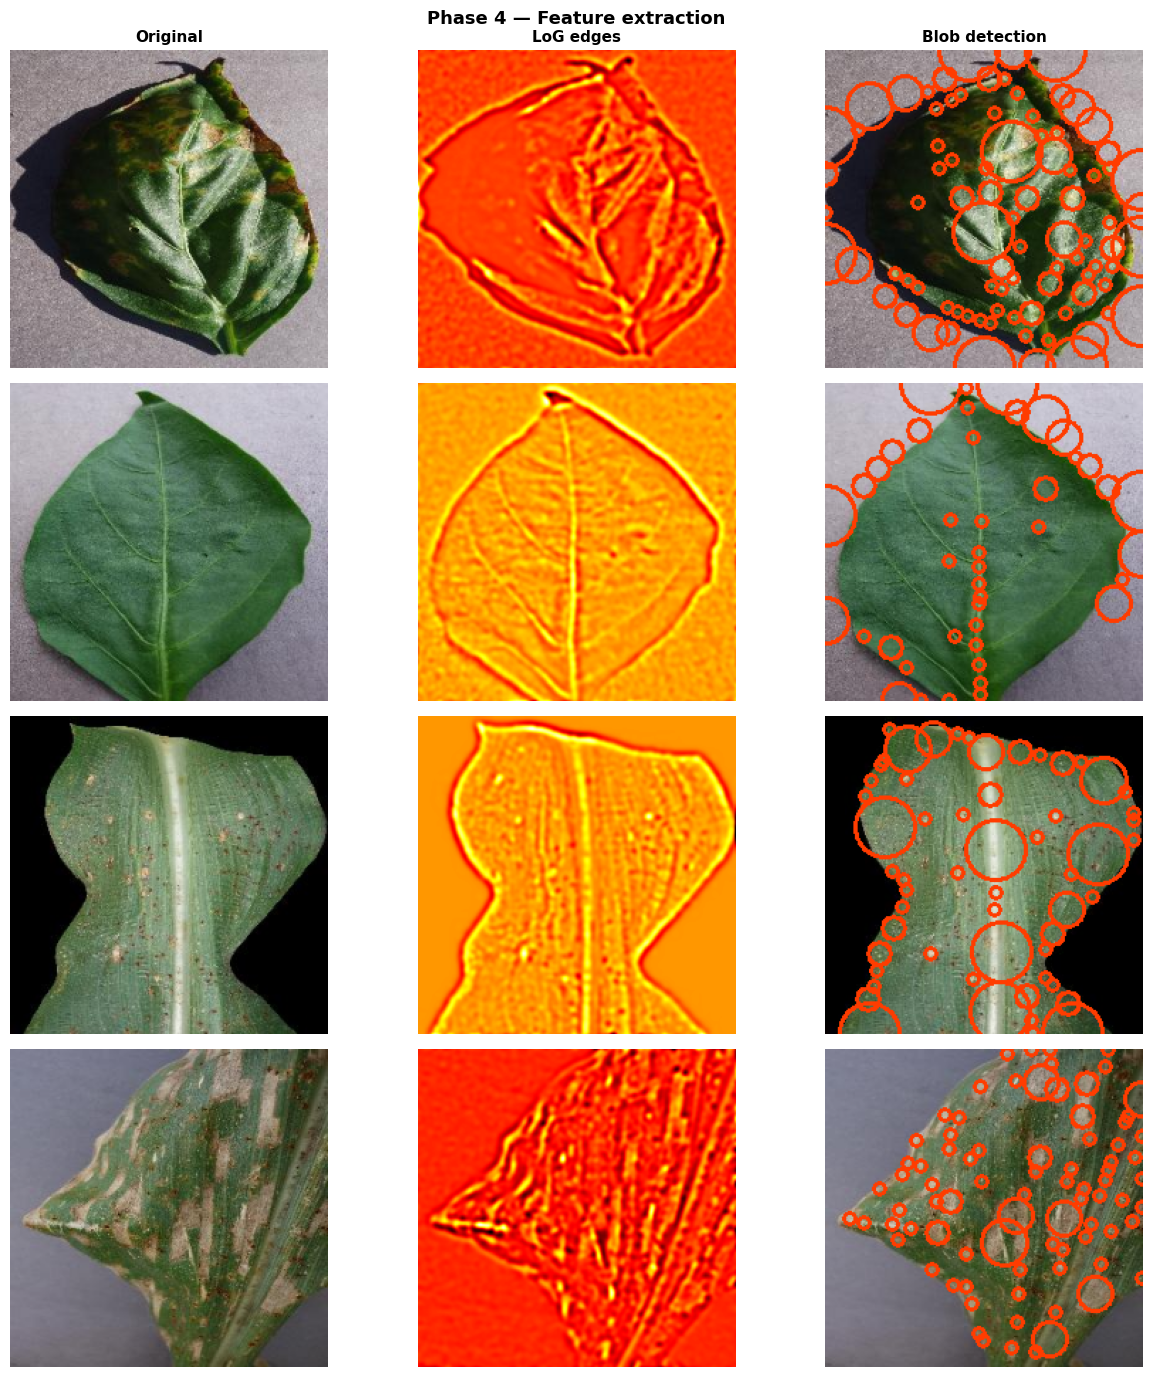

  Phase 4 complete!


In [ ]:
print("=" * 60)
print("  PHASE 4 — FEATURE EXTRACTION")
print("  LoG edge detection + Blob detection")
print("=" * 60)

def extract_features(img_path, img_size=(224, 224)):
    """
    1. LoG — detect sharp lesion edges
    2. Blob detection — locate individual disease spots
    """
    img   = cv2.imread(img_path)
    img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img   = cv2.resize(img, img_size)
    gray  = rgb2gray(img)

    # LoG edge detection
    log   = filters.laplace(
        filters.gaussian(gray, sigma=2))
    log_n = (log - log.min()) / (
        log.max() - log.min() + 1e-8)

    # Blob detection
    blobs = feature.blob_log(
        gray, min_sigma=3, max_sigma=15,
        num_sigma=5, threshold=0.05)
    blobs[:, 2] = blobs[:, 2] * np.sqrt(2)

    # Draw blobs
    blob_img = img.copy()
    for b in blobs:
        y, x, r = b
        cv2.circle(blob_img, (int(x), int(y)),
                   int(r), (255, 60, 0), 2)

    return img, log_n, blob_img, len(blobs)

# Visualize on 4 classes
fig, axes = plt.subplots(4, 3, figsize=(13, 14))
for col, t in enumerate(
        ["Original", "LoG edges", "Blob detection"]):
    axes[0][col].set_title(t, fontsize=11,
                            fontweight="bold")

for row, cls in enumerate(CLASS_NAMES[:4]):
    cls_dir  = os.path.join(TRAIN_DIR, cls)
    img_file = os.path.join(cls_dir,
                             os.listdir(cls_dir)[0])
    orig, log_img, blob_img, n = extract_features(img_file)

    axes[row][0].imshow(orig)
    axes[row][1].imshow(log_img, cmap="hot")
    axes[row][2].imshow(blob_img)
    axes[row][2].set_xlabel(f"{n} spots detected",
                             fontsize=8)
    axes[row][0].set_ylabel(cls, fontsize=7,
                             rotation=0,
                             labelpad=90, va="center")
    for ax in axes[row]:
        ax.axis("off")

plt.suptitle("Phase 4 — Feature extraction",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "features.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  Phase 4 complete!")

In [ ]:
print("=" * 60)
print("  PHASE 5 — DEEP LEARNING MODEL")
print("=" * 60)

def build_model(num_classes):
    # Pretrained EfficientNetB3 — freeze base
    base = EfficientNetB3(
        weights     = "imagenet",
        include_top = False,
        input_shape = (224, 224, 3)
    )
    base.trainable = False

    # Custom head
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation="softmax")(x)

    return Model(inputs=base.input, outputs=out), base

model, base_model = build_model(NUM_CLASSES)

model.compile(
    optimizer = Adam(learning_rate=LR_P1),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)

trainable   = sum(tf.size(w).numpy()
                  for w in model.trainable_weights)
frozen      = sum(tf.size(w).numpy()
                  for w in model.non_trainable_weights)

print(f"\n  Backbone      : EfficientNetB3 (ImageNet)")
print(f"  Input shape   : (224, 224, 3)")
print(f"  Output classes: (23)")
print(f"  Trainable now : {trainable:,}  (head only)")
print(f"  Frozen        : {frozen:,}  (base)")
print(f"\n  Head architecture:")
print(f"    GlobalAveragePooling2D")
print(f"    BatchNormalization")
print(f"    Dense(256, relu) → Dropout(0.4)")
print(f"    Dense(128, relu) → Dropout(0.3)")
print(f"    Dense({NUM_CLASSES}, softmax)")

  PHASE 5 — DEEP LEARNING MODEL
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  Backbone      : EfficientNetB3 (ImageNet)
  Input shape   : (224, 224, 3)
  Output classes: (23)
  Trainable now : 432,407  (head only)
  Frozen        : 10,786,607  (base)

  Head architecture:
    GlobalAveragePooling2D
    BatchNormalization
    Dense(256, relu) → Dropout(0.4)
    Dense(128, relu) → Dropout(0.3)
    Dense(23, softmax)


In [ ]:
from tensorflow.keras.callbacks import (ModelCheckpoint,
                                       EarlyStopping,
                                       ReduceLROnPlateau)

callbacks = [
    ModelCheckpoint(MODEL_PATH,
                    monitor="val_accuracy",
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_accuracy",
                  patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss",
                      factor=0.3, patience=3,
                      min_lr=1e-7, verbose=1)
]

print(f"Phase 1 — Training HEAD only")
print(f"Epochs: {EPOCHS_P1}  |  LR: {LR_P1}\n")

history1 = model.fit(
    train_gen,
    epochs          = EPOCHS_P1,
    validation_data = val_gen,
    callbacks       = callbacks,
    verbose         = 1
)

p1_best = max(history1.history["val_accuracy"])
print(f"\n  Phase 1 best val accuracy: {p1_best*100:.2f}%")

Phase 1 — Training HEAD only
Epochs: 10  |  LR: 0.001

Epoch 1/10
 668/2132 ━━━━━━━━━━━━━━━━━━━━ 4:21:08 11s/step - accuracy: 0.0787 - loss: 3.2461

In [ ]:
# Unfreeze all layers
model.trainable = True
model.compile(
    optimizer = Adam(learning_rate=LR_P2),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)

total = sum(tf.size(w).numpy()
            for w in model.trainable_weights)
print(f"Phase 2 — Fine-tuning FULL model")
print(f"Trainable params: {total:,}")
print(f"Epochs: {EPOCHS_P2}  |  LR: {LR_P2}\n")

history2 = model.fit(
    train_gen,
    epochs          = EPOCHS_P2,
    validation_data = val_gen,
    callbacks       = callbacks,
    verbose         = 1
)

p2_best = max(history2.history["val_accuracy"])
print(f"\n  Phase 2 best val accuracy: {p2_best*100:.2f}%")

In [ ]:
acc   = history1.history["accuracy"]     + history2.history["accuracy"]
val   = history1.history["val_accuracy"] + history2.history["val_accuracy"]
loss  = history1.history["loss"]         + history2.history["loss"]
vloss = history1.history["val_loss"]     + history2.history["val_loss"]
ep    = range(1, len(acc)+1)
p2s   = len(history1.history["accuracy"]) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for ax, tr, vl, ylabel, title in [
    (ax1, acc,  val,   "Accuracy", "Accuracy"),
    (ax2, loss, vloss, "Loss",     "Loss")]:
    ax.plot(ep, tr, "b-o", ms=3, label="Train")
    ax.plot(ep, vl, "r-o", ms=3, label="Validation")
    ax.axvline(p2s, color="gray", ls="--",
               alpha=0.7, label="Fine-tune start")
    ax.fill_between([1, p2s], 0, 1,
                    alpha=0.05, color="blue")
    ax.fill_between([p2s, len(ep)+1], 0, 1,
                    alpha=0.05, color="orange")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)

ax1.set_ylim([0, 1.05])
plt.suptitle("Phase 5 — Training curves",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  Saved → training_curves.png")

In [ ]:
print("=" * 60)
print("  PHASE 6 — VALIDATION & EVALUATION")
print("=" * 60)

model = tf.keras.models.load_model(MODEL_PATH)

test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\n  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Target ≥ 90%  : "
      f"{'✓ ACHIEVED' if test_acc>=0.90 else '✗ not yet'}")

In [ ]:
print("\n  Generating predictions...")
y_pred = np.argmax(
    model.predict(test_gen, verbose=1), axis=1)
y_true = test_gen.classes

# Classification report
report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES, digits=4)
print("\n" + "=" * 60)
print(report)

# Save report
with open(os.path.join(SAVE_DIR,
          "classification_report.txt"), "w") as f:
    f.write(f"Test Accuracy: {test_acc*100:.2f}%\n\n")
    f.write(report)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(22, 20))
sns.heatmap(cm, annot=True, fmt="d",
            cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.4,
            annot_kws={"size": 8})
plt.title("Phase 6 — Confusion Matrix",
          fontsize=15, pad=15)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual",    fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,
            "confusion_matrix.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  Saved → confusion_matrix.png")

In [ ]:
print("=" * 60)
print("  PHASE 7 — SAVE & DEPLOY")
print("=" * 60)

# Save full Keras model
model.save(MODEL_PATH)
print(f"\n  Keras model saved  → {MODEL_PATH}")

# Convert to TFLite (for mobile app)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

size_mb = os.path.getsize(TFLITE_PATH) / (1024*1024)
print(f"  TFLite saved       → {TFLITE_PATH}  "
      f"({size_mb:.1f} MB)")

# Save class names
with open(LABELS_PATH, "w") as f:
    json.dump(CLASS_NAMES, f, indent=2)
print(f"  Class names saved  → {LABELS_PATH}")

# Final summary
print("\n" + "=" * 60)
print("  ALL PHASES COMPLETE!")
print("=" * 60)
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Model size    : {size_mb:.1f} MB (TFLite)")
print(f"  Classes       : {NUM_CLASSES}")
print(f"\n  Files saved to Drive:")
files = ["best_model.keras", "leaf_disease.tflite",
         "class_names.json", "training_curves.png",
         "confusion_matrix.png",
         "classification_report.txt",
         "augmentation.png", "segmentation.png",
         "features.png"]
for f in files:
    p = os.path.join(SAVE_DIR, f)
    if os.path.exists(p):
        kb = os.path.getsize(p)/1024
        print(f"    ✓  {f:<35} {kb:>7.1f} KB")

In [3]:
!git clone https://github.com/PavithraJayarathna/PlantDiseaseDetection.git
%cd PlantDiseaseDetection

Cloning into 'PlantDiseaseDetection'...
/content/PlantDiseaseDetection


In [4]:
!ls /content

drive  PlantDiseaseDetection  sample_data


In [ ]:
!find /content/drive -name "*.ipynb"

/content/drive/MyDrive/Colab Notebooks/Plant_Leaf_disease.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of Untitled3_(1) (1).ipynb
/content/drive/MyDrive/Colab Notebooks/ETHUSDT project (1).ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled6.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled7.ipynb
/content/drive/MyDrive/Colab Notebooks/ETHUSDT project.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of Day 06.ipynb
/content/drive/MyDrive/Colab Notebooks/Group21.ipynb
/content/drive/MyDrive/Untitled3_(1) (1).ipynb
